In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


In [2]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import sys

ROOT = Path().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype  = "float32"  # DV: recomendado

torch.manual_seed(0)
if device == "cuda":
    torch.cuda.manual_seed_all(0)

print("device:", device, " dtype:", dtype, " ROOT:", ROOT)


device: cpu  dtype: float32  ROOT: C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025


In [3]:
import importlib
import src.trainer.schrodinger_train as sch_train
import src.nn.DVPDESolver as dv_solver_mod

importlib.reload(sch_train)
importlib.reload(dv_solver_mod)

from src.trainer.schrodinger_train import train
from src.nn.DVPDESolver import DVPDESolver

from src.problems.schrodinger import build_eq_params, sanity_check
from src.problems.schrodinger.problem import build_problem
from src.utils.logger import Logging

print("Imports OK.")


Imports OK.


In [4]:
eq_params = build_eq_params(
    "barrier",
    L=1.0,
    T=0.2,
    n_level=1,
    mass=1.0,
    hbar=1.0,

    # barrera
    V0=10.0,            # sube a 50.0 luego
    barrier_width=0.2,
    x_center=0.6,

    num_grid=1000,      # para exact/diagnóstico
)

san = sanity_check(eq_params)
print("eq_params:", eq_params)
print("sanity:", san)


eq_params: {'example': 'barrier', 'L': 1.0, 'T': 0.2, 'mass': 1.0, 'hbar': 1.0, 'n_level': 1, 'x_min': 0.0, 'x_max': 1.0, 'omega': 1.0, 'V0': 10.0, 'barrier_width': 0.2, 'x_center': 0.6, 'num_grid': 1000}
sanity: {'V_min': 0.0, 'V_max': 10.0, 'psi0_norm': 0.9974936778483945, 'psiT_norm': 0.9974936778483945}


In [5]:
args = {
    "eq_params": eq_params,
    "device": device,
    "dtype": dtype,
    "problem": "schrodinger",

    # training
    "epochs": 400,
    "warmup_epochs": 0,
    "lr": 1e-3,
    "batch_size": 64,
    "print_every": 10,

    # losses
    "w_pde": 0.0,
    "w_ic":  800.0,
    "w_norm": 0.0,

    # parte imaginaria: ayuda mucho en DV
    "w_pde_i": 1.0,
    "w_ic_i":  5.0,

    # BC dura (Dirichlet en 0 y L)
    "hard_bc": True,
    "w_bc": 0.0,
    "hard_bc_power": 1.0,   # prueba 2.0 si ves bordes con ruido
    "hard_bc_scale": 4.0,

    # warmup/val
    "ic_grid": True,
    "N_norm": 400,
    "N_val": 400,

    # DV circuit
    "num_qubits": 4,
    "num_quantum_layers": 2,
    "shots": None,
    "noise": False,
    "encoding": "angle",
    "q_ansatz": "sim_circ_19",

    # hybrid net
    "classic_network": [2, 64, 64, 2],

    # performance
    "pde_chunk_size": 64,
    "l2_every": 10,
    "global_phase": True,
    "global_phase_spatial_only": True,
    "global_phase_omega_init": 5.0,
    "use_lbfgs": False,
    "angle_squash": True,

}

logger = Logging("./results/models/checkpoints/smoke_schrodinger", "barrier_DV")
model = DVPDESolver(args, logger, device=torch.device(device))
model.args = args
model.draw_quantum_circuit_flag = False

print("DV model built.")
print("hard_bc:", model.args.get("hard_bc"), "example:", model.args["eq_params"]["example"])


DV model built.
hard_bc: True example: barrier


In [6]:
param_dtype = next(model.parameters()).dtype
param_device = next(model.parameters()).device

t_test = torch.rand(8, 1, device=param_device, dtype=param_dtype) * eq_params["T"]
x_test = torch.rand(8, 1, device=param_device, dtype=param_dtype) * (eq_params["x_max"] - eq_params["x_min"]) + eq_params["x_min"]

y = model(torch.cat([t_test, x_test], dim=1))
print("forward ok ->", y.shape, y.dtype, y.device)


forward ok -> torch.Size([8, 2]) torch.float32 cpu


In [7]:
# con hard_bc=True, N_b puede ser 0 para ahorrar
train(model, N_f=256, N_b=0, N_0=512)


INFO:src.utils.logger:It: 1, Loss: 8.170e+02, Loss_res: 7.259e-01,  Loss_bcs: 0.000e+00, Loss_ut_ics: 1.021e+00, Loss_norm: 9.752e-01, Loss_gauge: 0.000e+00, w_pde: 0.00e+00, L^2_error: 1.013e+00, lr: 1.000e-03, Time: 9.79e-01
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/smoke_schrodinger\2025-12-23_13-28-19-124154_barrier_DV\model.pth
INFO:src.utils.logger:Model weights saved to ./results/models/checkpoints/smoke_schrodinger\2025-12-23_13-28-19-124154_barrier_DV\model_weights.pth
INFO:src.utils.logger:It: 10, Loss: 7.462e+02, Loss_res: 1.668e+00,  Loss_bcs: 0.000e+00, Loss_ut_ics: 9.328e-01, Loss_norm: 9.711e-01, Loss_gauge: 0.000e+00, w_pde: 0.00e+00, L^2_error: 1.052e+00, lr: 1.000e-03, Time: 9.00e+00
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/smoke_schrodinger\2025-12-23_13-28-19-124154_barrier_DV\model.pth
INFO:src.utils.logger:Model weights saved to ./results/models/checkpoints/smoke_schrodinger\2025-12-23_13-28-19-124154_ba

In [8]:
device_ = next(model.parameters()).device
dtype_  = next(model.parameters()).dtype
problem = build_problem(eq_params, device=device_, dtype=dtype_)

x = torch.linspace(problem["x_min"], problem["x_max"], 400, device=device_, dtype=dtype_).reshape(-1,1)
t0 = torch.zeros_like(x)
tT = torch.full_like(x, float(problem["T"]))

with torch.no_grad():
    psi0 = model(torch.cat([t0, x], dim=1))
    psiT = model(torch.cat([tT, x], dim=1))

prob0 = psi0[:,0]**2 + psi0[:,1]**2
probT = psiT[:,0]**2 + psiT[:,1]**2
norm0 = torch.trapz(prob0, x.squeeze(-1)).item()
normT = torch.trapz(probT, x.squeeze(-1)).item()

tline = torch.linspace(0.0, float(problem["T"]), 200, device=device_, dtype=dtype_).reshape(-1,1)
with torch.no_grad():
    psi_left  = model(torch.cat([tline, torch.full_like(tline, float(problem["x_min"]))], dim=1))
    psi_right = model(torch.cat([tline, torch.full_like(tline, float(problem["x_max"]))], dim=1))

max_left  = torch.sqrt(psi_left[:,0]**2  + psi_left[:,1]**2).max().item()
max_right = torch.sqrt(psi_right[:,0]**2 + psi_right[:,1]**2).max().item()

print("Norm pred t=0:", norm0)
print("Norm pred t=T:", normT)
print("max |psi(t,x_min)|:", max_left)
print("max |psi(t,x_max)|:", max_right)


Norm pred t=0: 0.9947768449783325
Norm pred t=T: 0.9947768449783325
max |psi(t,x_min)|: 0.0
max |psi(t,x_max)|: 0.0


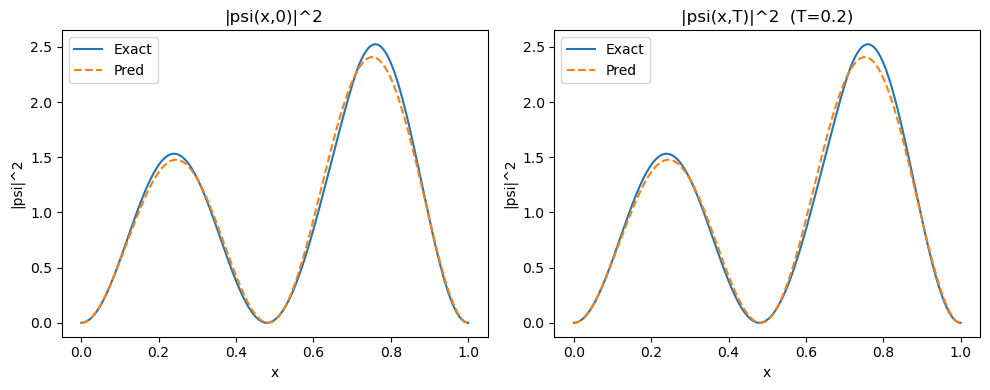

In [9]:
import numpy as np

x_plot = torch.linspace(problem["x_min"], problem["x_max"], 600, device=device_, dtype=dtype_).reshape(-1,1)
t0p = torch.zeros_like(x_plot)
tTp = torch.full_like(x_plot, float(problem["T"]))

with torch.no_grad():
    re0_ex, im0_ex, _ = problem["exact"](problem["n_level"], t0p, x_plot)
    reT_ex, imT_ex, _ = problem["exact"](problem["n_level"], tTp, x_plot)

    y0 = model(torch.cat([t0p, x_plot], dim=1))
    yT = model(torch.cat([tTp, x_plot], dim=1))

re0_pr, im0_pr = y0[:,0:1], y0[:,1:2]
reT_pr, imT_pr = yT[:,0:1], yT[:,1:2]

p0_ex = (re0_ex**2 + im0_ex**2).detach().cpu().numpy().squeeze()
p0_pr = (re0_pr**2 + im0_pr**2).detach().cpu().numpy().squeeze()
pT_ex = (reT_ex**2 + imT_ex**2).detach().cpu().numpy().squeeze()
pT_pr = (reT_pr**2 + imT_pr**2).detach().cpu().numpy().squeeze()
xx = x_plot.detach().cpu().numpy().squeeze()

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(xx, p0_ex, label="Exact")
plt.plot(xx, p0_pr, "--", label="Pred")
plt.title("|psi(x,0)|^2")
plt.xlabel("x"); plt.ylabel("|psi|^2"); plt.legend()

plt.subplot(1,2,2)
plt.plot(xx, pT_ex, label="Exact")
plt.plot(xx, pT_pr, "--", label="Pred")
plt.title(f"|psi(x,T)|^2  (T={float(problem['T'])})")
plt.xlabel("x"); plt.ylabel("|psi|^2"); plt.legend()

plt.tight_layout()
plt.show()


In [10]:
problem = build_problem(eq_params, device=device, dtype=next(model.parameters()).dtype)
x = torch.linspace(problem["x_min"], problem["x_max"], 300, device=device, dtype=next(model.parameters()).dtype).reshape(-1,1)
t0 = torch.zeros_like(x)

with torch.no_grad():
    re_e, im_e, _ = problem["exact"](problem["n_level"], t0, x)
    rho_e = (re_e**2 + im_e**2)

    out = model(torch.cat([t0, x], dim=1))
    re_p, im_p = out[:,0:1], out[:,1:2]
    rho_p = (re_p**2 + im_p**2)

    l2_rho = torch.sqrt(torch.mean((rho_p - rho_e)**2)) / (torch.sqrt(torch.mean(rho_e**2)) + 1e-12)

print("L2_rel en densidad (t=0):", float(l2_rho))
print("rho_pred min/max:", float(rho_p.min()), float(rho_p.max()))


L2_rel en densidad (t=0): 0.04844912886619568
rho_pred min/max: 0.0 2.407147169113159


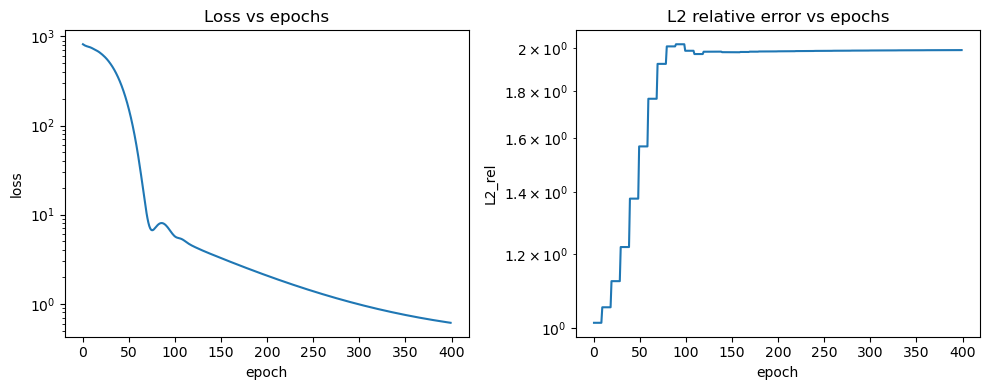

In [11]:
import numpy as np

loss_hist = np.array(getattr(model, "loss_history", []), dtype=float)
l2_hist   = np.array(getattr(model, "l2_rel_history", []), dtype=float)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(loss_hist)
plt.yscale("log")
plt.title("Loss vs epochs")
plt.xlabel("epoch"); plt.ylabel("loss")

plt.subplot(1,2,2)
plt.plot(l2_hist)
plt.yscale("log")
plt.title("L2 relative error vs epochs")
plt.xlabel("epoch"); plt.ylabel("L2_rel")

plt.tight_layout()
plt.show()


In [12]:
import torch

problem = build_problem(eq_params, device=device, dtype=next(model.parameters()).dtype)

x = torch.linspace(problem["x_min"], problem["x_max"], 400, device=device, dtype=next(model.parameters()).dtype).reshape(-1,1)
tT = torch.full_like(x, float(problem["T"]))

with torch.no_grad():
    re_e, im_e, _ = problem["exact"](problem["n_level"], tT, x)
    psi_e = re_e + 1j*im_e

    out = model(torch.cat([tT, x], dim=1))
    psi_p = out[:,0:1] + 1j*out[:,1:2]

    # fase óptima alpha
    alpha = (torch.mean(torch.conj(psi_p)*psi_e) / (torch.mean(torch.conj(psi_p)*psi_p) + 1e-12))
    l2_phase = torch.sqrt(torch.mean(torch.abs(alpha*psi_p - psi_e)**2)) / (torch.sqrt(torch.mean(torch.abs(psi_e)**2)) + 1e-12)

print("L2_rel (fase corregida):", float(l2_phase))



L2_rel (fase corregida): 0.027191223576664925


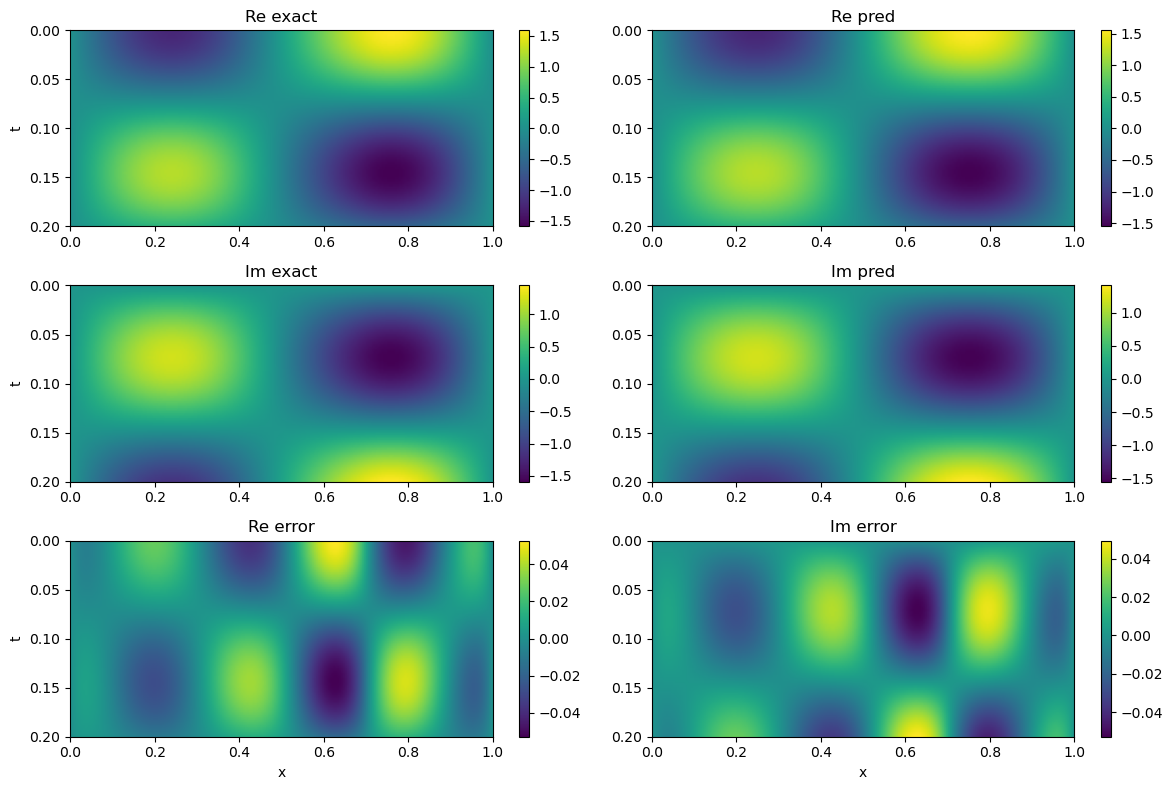

In [16]:
import numpy as np

Nt, Nx = 80, 220
t_grid = torch.linspace(0.0, float(problem["T"]), Nt, device=device_, dtype=dtype_).reshape(-1,1)
x_grid = torch.linspace(problem["x_min"], problem["x_max"], Nx, device=device_, dtype=dtype_).reshape(-1,1)

# mallado tipo (Nt*Nx, 1)
TT = t_grid.repeat(1, Nx).reshape(-1,1)
XX = x_grid.repeat(Nt, 1)

with torch.no_grad():
    re_ex, im_ex, _ = problem["exact"](problem["n_level"], TT, XX)
    y_pr = model(torch.cat([TT, XX], dim=1))
    re_pr, im_pr = y_pr[:,0:1], y_pr[:,1:2]

re_ex = re_ex.reshape(Nt, Nx).detach().cpu().numpy()
im_ex = im_ex.reshape(Nt, Nx).detach().cpu().numpy()
re_pr = re_pr.reshape(Nt, Nx).detach().cpu().numpy()
im_pr = im_pr.reshape(Nt, Nx).detach().cpu().numpy()

re_er = re_pr - re_ex
im_er = im_pr - im_ex

extent = [float(problem["x_min"]), float(problem["x_max"]), float(problem["T"]), 0.0]

plt.figure(figsize=(12,8))

plt.subplot(3,2,1); plt.imshow(re_ex, aspect="auto", extent=extent); plt.title("Re exact"); plt.ylabel("t"); plt.colorbar()
plt.subplot(3,2,2); plt.imshow(re_pr, aspect="auto", extent=extent); plt.title("Re pred");  plt.colorbar()

plt.subplot(3,2,3); plt.imshow(im_ex, aspect="auto", extent=extent); plt.title("Im exact"); plt.ylabel("t"); plt.colorbar()
plt.subplot(3,2,4); plt.imshow(im_pr, aspect="auto", extent=extent); plt.title("Im pred");  plt.colorbar()

plt.subplot(3,2,5); plt.imshow(re_er, aspect="auto", extent=extent); plt.title("Re error"); plt.xlabel("x"); plt.ylabel("t"); plt.colorbar()
plt.subplot(3,2,6); plt.imshow(im_er, aspect="auto", extent=extent); plt.title("Im error"); plt.xlabel("x"); plt.colorbar()

plt.tight_layout()
plt.show()


In [15]:
problem = build_problem(eq_params, device=device, dtype=next(model.parameters()).dtype)

t0 = torch.zeros(1,1, device=device, dtype=next(model.parameters()).dtype)
x0 = torch.tensor([[0.37]], device=device, dtype=next(model.parameters()).dtype)

_, _, E = problem["exact"](problem["n_level"], t0, x0)
omega_star = float((E / problem["hbar"]).detach().cpu())

print("omega_star =", omega_star)

# set + freeze
model.global_phase_omega.data.fill_(omega_star)
model.global_phase_omega.requires_grad_(False)


omega_star = 21.444286346435547


Parameter containing:
tensor(21.4443)